# `pyscdblfinder` vs R `scDblFinder` — parity comparison

This notebook runs **`pyscdblfinder`** (the Python port) and the original **R `scDblFinder`** on the same single-cell dataset, then uses **omicverse** (not scanpy) for visualization.

Since both implementations use xgboost internally with different RNGs, exact per-cell score equality is impossible — instead we check:
* overlap of the doublet sets (Venn),
* singlet/doublet classification agreement (confusion matrix),
* Spearman correlation of the per-cell scores,
* per-cluster doublet fractions,
* UMAP overlays of each method's calls.

In [1]:
from __future__ import annotations

import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import omicverse as ov

import pyscdblfinder as psdf

ov.plot_set()
RSCRIPT = "/scratch/users/steorra/env/CMAP/bin/Rscript"
DRIVER  = Path("r_driver_pbmc3k.R").resolve()
WORK = Path("./compare_out"); WORK.mkdir(exist_ok=True)
print("omicverse", ov.__version__, "— pyscdblfinder", psdf.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.1.2rc1 — pyscdblfinder 0.1.0


## 1. Load data via omicverse + light QC

Pull pbmc3k from omicverse and apply QC without any doublet detection yet.

In [2]:
adata = ov.datasets.pbmc3k()
ov.pp.qc(adata,
         tresh={'mito_perc': 20, 'nUMIs': 500, 'detected_genes': 250},
         doublets=False)
print(adata)

 Loading PBMC 3k dataset (raw)
⚠️ File ./data/pbmc3k_raw.h5ad already exists
 Loading data from ./data/pbmc3k_raw.h5ad


✅ Successfully loaded: 2700 cells × 32738 genes


🖥️ Using CPU mode for QC...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 106                │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 13                 │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range 

   ✓ Final filtering: 0 cells, 19,024 genes removed

📊 Step 4: Doublet detection disabled

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 0.1622s                                                 │
│  Shape:    2,700 x 32,738 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ passing_mt (bool)                                    │
│           │ ✚ passing_nUMIs (bool)                     

In [3]:
# Dump counts so the R driver reads the exact same matrix
import scipy.sparse as sp
counts_path = WORK / 'counts.tsv'
if not counts_path.exists():
    X = adata.X.T.toarray() if sp.issparse(adata.X) else np.asarray(adata.X).T
    pd.DataFrame(X, index=adata.var_names, columns=adata.obs_names).to_csv(counts_path, sep='\t')
print('counts →', counts_path, counts_path.stat().st_size // 1024, 'KB')

counts → compare_out/counts.tsv 345744 KB


## 2. Run R `scDblFinder`

Canonical implementation from Bioconductor. `dbr=0.075` matches the 10x Chromium default.

In [4]:
r_out = WORK / 'r_out'; r_out.mkdir(exist_ok=True)
if not (r_out / 'r_result.tsv').exists():
    proc = subprocess.run([RSCRIPT, str(DRIVER), str(counts_path), str(r_out), '0.075'],
                          capture_output=True, text=True)
    print(proc.stdout[-400:])
    if proc.returncode != 0:
        print('STDERR:', proc.stderr[-800:])
        raise RuntimeError('R driver failed')
r_res = pd.read_csv(r_out / 'r_result.tsv', sep='\t').set_index('cell')
print('R scDblFinder doublets:', (r_res['class']=='doublet').sum(), '/', len(r_res))

[R] reading compare_out/counts.tsv
[R] running scDblFinder (dbr=0.075) on 2700 cells × 32738 genes
[R] wrote 2700 rows → compare_out/r_out/r_result.tsv (172 doublets called)

R scDblFinder doublets: 172 / 2700


## 3. Run `pyscdblfinder`

In [5]:
sdf = psdf.ScDblFinder(adata.copy(), random_state=0)
sdf.run(dbr=0.075, dims=15, n_features=1000, artificial_doublets=3000,
        iter=2, nrounds=0.25, verbose=True)
adata.obs['scDblFinder_py_score'] = sdf.adata.obs['scDblFinder_score']
adata.obs['scDblFinder_py_class'] = sdf.adata.obs['scDblFinder_class'].astype('category')
print('pyscdblfinder doublets:', (adata.obs['scDblFinder_py_class']=='doublet').sum(),
      '/', adata.n_obs)

[ScDblFinder] 2700 cells × 32738 genes
[scDblFinder] creating ~3000 artificial doublets (random)


[scDblFinder] computing cxds + size features


[scDblFinder] PCA (dims=15)


[scDblFinder] kNN features


[scDblFinder] xgboost scoring
[scDblscore] iter=0  excluding 258 cells from training


[scDblscore] iter=1  excluding 201 cells from training


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.477
pyscdblfinder doublets: 135 / 2700


In [6]:
# Join R scores/classes onto the same AnnData
adata.obs['scDblFinder_R_score'] = r_res['score'].reindex(adata.obs_names).astype(float).values
adata.obs['scDblFinder_R_class'] = r_res['class'].reindex(adata.obs_names).astype('category').values

def combo(a, b):
    return {('singlet','singlet'):'both singlet',
            ('doublet','doublet'):'both doublet',
            ('singlet','doublet'):'R-only',
            ('doublet','singlet'):'py-only'}[(a, b)]
adata.obs['doublet_agree'] = pd.Categorical([
    combo(a, b) for a, b in zip(adata.obs['scDblFinder_py_class'],
                                 adata.obs['scDblFinder_R_class'])])
adata.obs['doublet_agree'].value_counts()

doublet_agree
both singlet    2495
both doublet     102
R-only            70
py-only           33
Name: count, dtype: int64

## 4. Overlap of doublet sets — `ov.pl.venn`

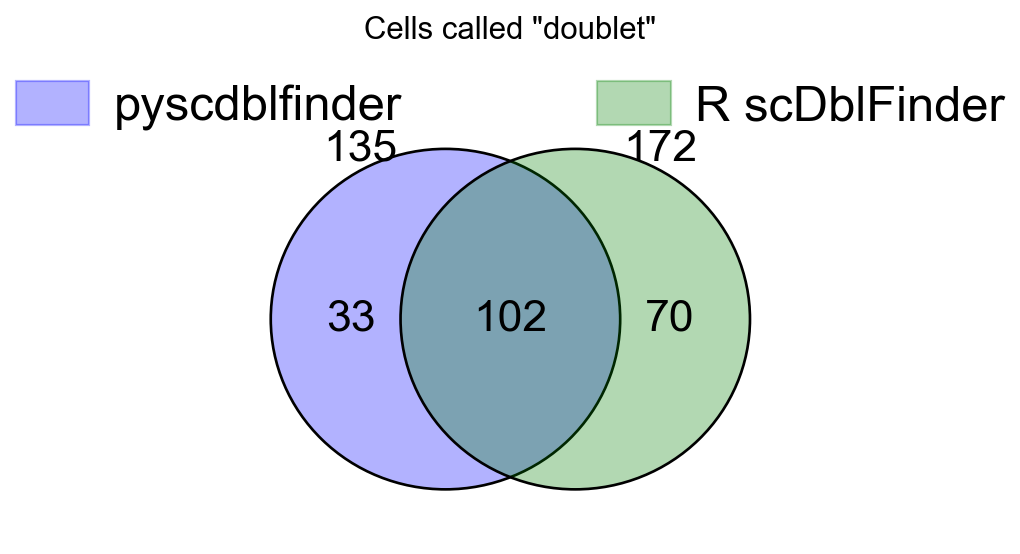

In [7]:
py_set = set(adata.obs_names[adata.obs['scDblFinder_py_class']=='doublet'])
r_set  = set(adata.obs_names[adata.obs['scDblFinder_R_class']=='doublet'])

fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.venn(sets={'pyscdblfinder': py_set, 'R scDblFinder': r_set}, ax=ax, fontsize=10)
ax.set_title('Cells called "doublet"')
plt.show()

## 5. Confusion matrix

scDblFinder_R_class   singlet  doublet
scDblFinder_py_class                  
singlet                  2495       70
doublet                    33      102


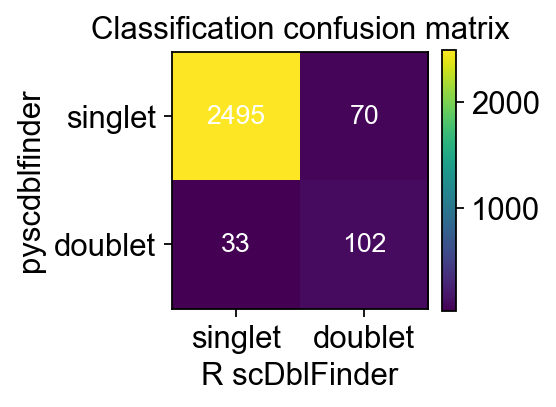

Agreement: 96.185%


In [8]:
conf = pd.crosstab(adata.obs['scDblFinder_py_class'], adata.obs['scDblFinder_R_class']).reindex(
    index=['singlet','doublet'], columns=['singlet','doublet']).fillna(0).astype(int)
print(conf)

fig, ax = plt.subplots(figsize=(3.5,3))
im = ax.imshow(conf.values, cmap='viridis')
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(conf.values[i, j]), ha='center', va='center', color='white', fontsize=12)
ax.set_xticks([0,1]); ax.set_xticklabels(conf.columns)
ax.set_yticks([0,1]); ax.set_yticklabels(conf.index)
ax.set_xlabel('R scDblFinder'); ax.set_ylabel('pyscdblfinder')
ax.set_title('Classification confusion matrix')
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

print(f"Agreement: {(adata.obs['scDblFinder_py_class']==adata.obs['scDblFinder_R_class']).mean():.3%}")

## 6. Preprocess + cluster via omicverse

In [9]:
adata_viz = adata.copy()
adata_viz.layers['counts'] = adata_viz.X.copy()
ov.pp.preprocess(adata_viz, mode='shiftlog|pearson', n_HVGs=2000)
adata_viz.raw = adata_viz
adata_viz = adata_viz[:, adata_viz.var.highly_variable_features]
ov.pp.scale(adata_viz)
ov.pp.pca(adata_viz, layer='scaled', n_pcs=30)
ov.pp.neighbors(adata_viz, n_neighbors=15, use_rep='scaled|original|X_pca')
ov.pp.leiden(adata_viz, resolution=0.5)
ov.pp.umap(adata_viz)
for c in ('scDblFinder_py_class','scDblFinder_R_class','doublet_agree',
          'scDblFinder_py_score','scDblFinder_R_score'):
    adata_viz.obs[c] = adata.obs[c].reindex(adata_viz.obs_names).values

🔍 [2026-04-18 02:42:16] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 16634/32738 genes are kept.
    Among 16634 genes, 14702 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 0 highly-expressed genes from normalization computation
   Excluded genes: []

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,700 cells × 14,702 genes
   ✓ Runtime: 0.12s



🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 14,702 total (13.6%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.42 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (2700, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (7.15s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 7.155s                                                  │
│  Shape:    2,700 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 2700x30)                               │
│           │ ✚ scaled|original|X_pca (array, 2700x30)               │
│         

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 2,700 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.5698s                                                 │
│  Shape:    2,700 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 2,700 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.6403s                                                 │
│  Shape:    2,700 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 2700x2)                               │
│                 

## 7. UMAP overlays — `ov.pl.embedding`

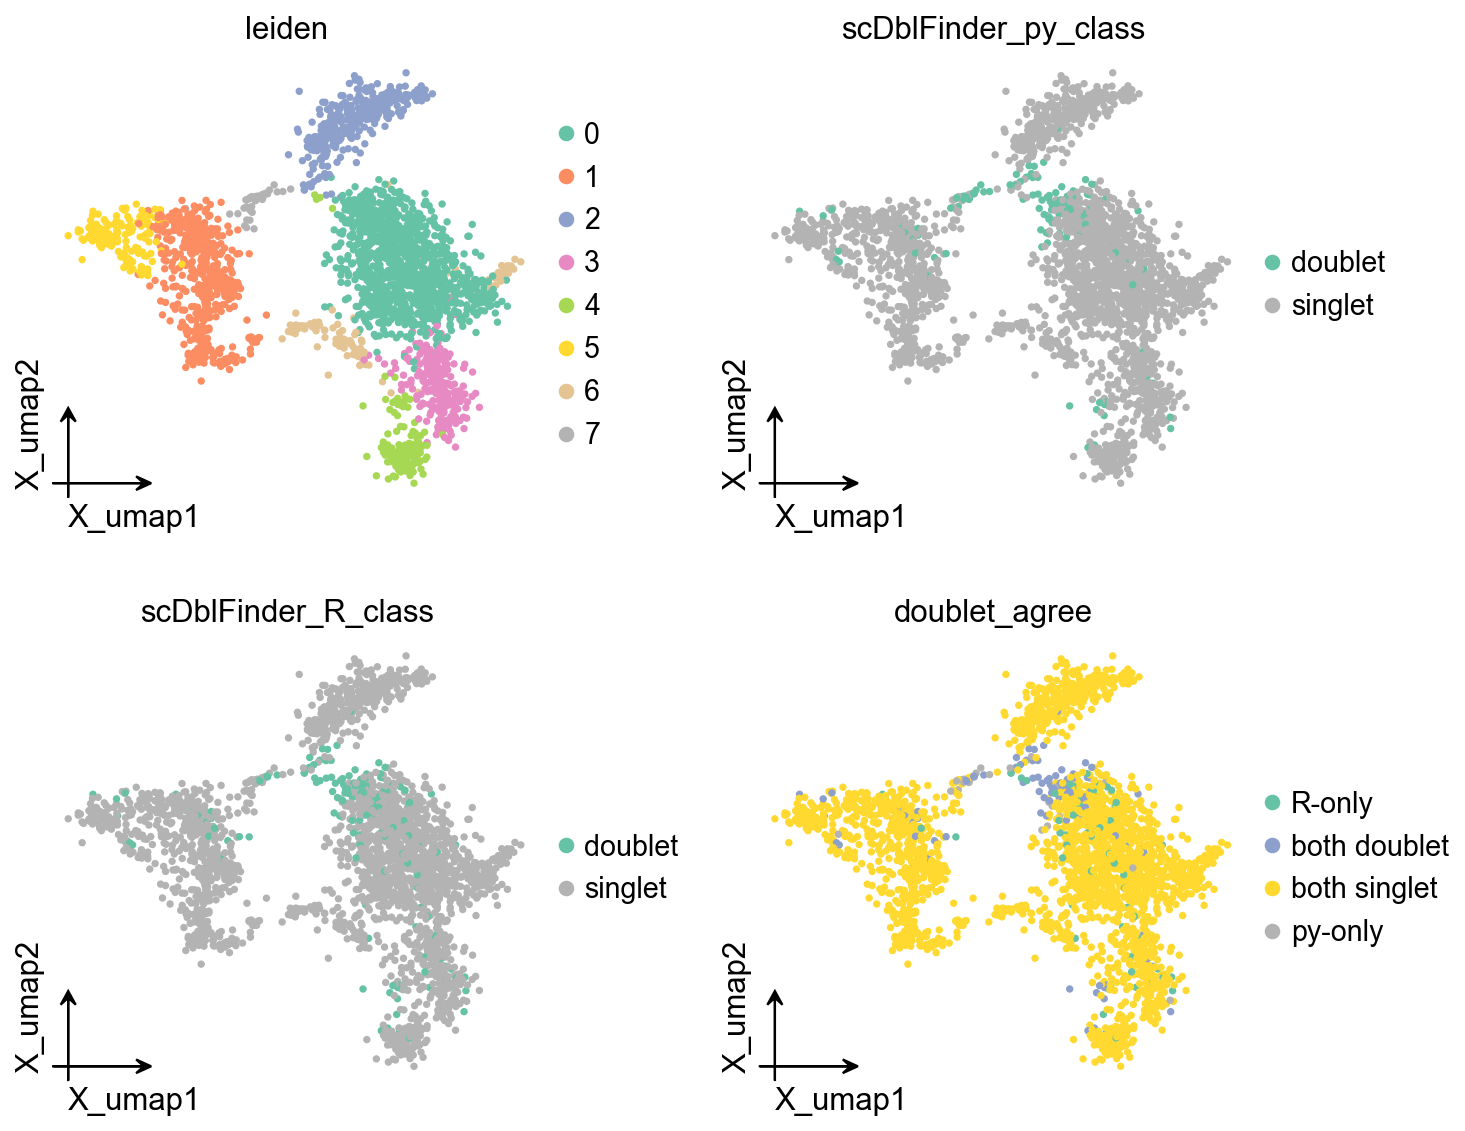

In [10]:
ov.pl.embedding(adata_viz, basis='X_umap',
                color=['leiden','scDblFinder_py_class','scDblFinder_R_class','doublet_agree'],
                palette='Set2', frameon='small', ncols=2, wspace=0.25, show=False)
plt.show()

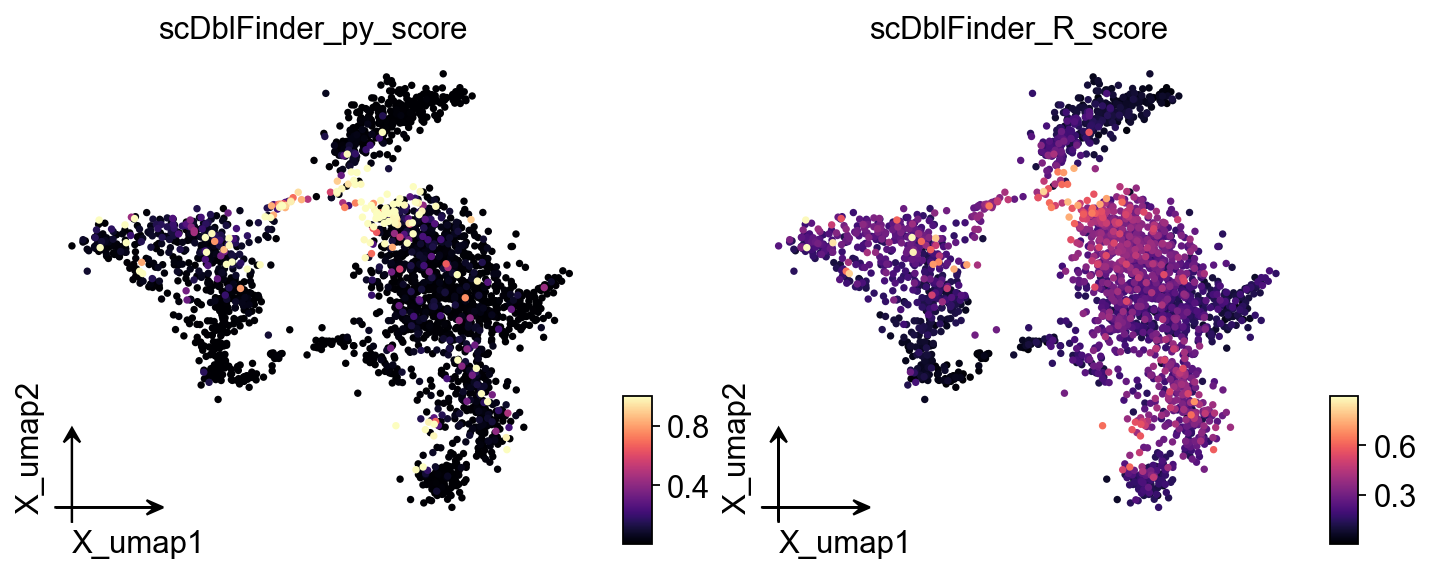

In [11]:
ov.pl.embedding(adata_viz, basis='X_umap',
                color=['scDblFinder_py_score','scDblFinder_R_score'],
                cmap='magma', frameon='small', ncols=2, wspace=0.25, show=False)
plt.show()

## 8. Per-cluster doublet fraction — `ov.pl.cellproportion`

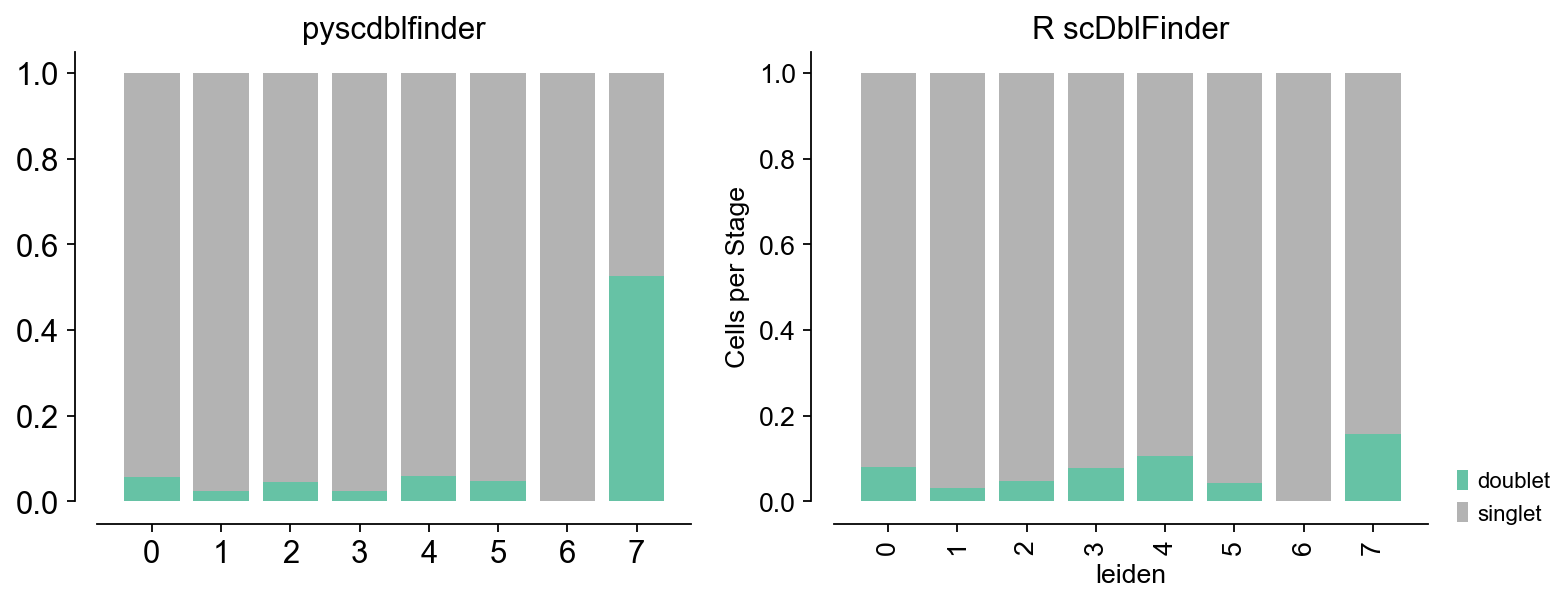

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ov.pl.cellproportion(adata_viz, celltype_clusters='scDblFinder_py_class',
                     groupby='leiden', ax=axes[0], legend=True)
axes[0].set_title('pyscdblfinder')
ov.pl.cellproportion(adata_viz, celltype_clusters='scDblFinder_R_class',
                     groupby='leiden', ax=axes[1], legend=True)
axes[1].set_title('R scDblFinder')
plt.tight_layout(); plt.show()

## 9. Score correlation — scatter

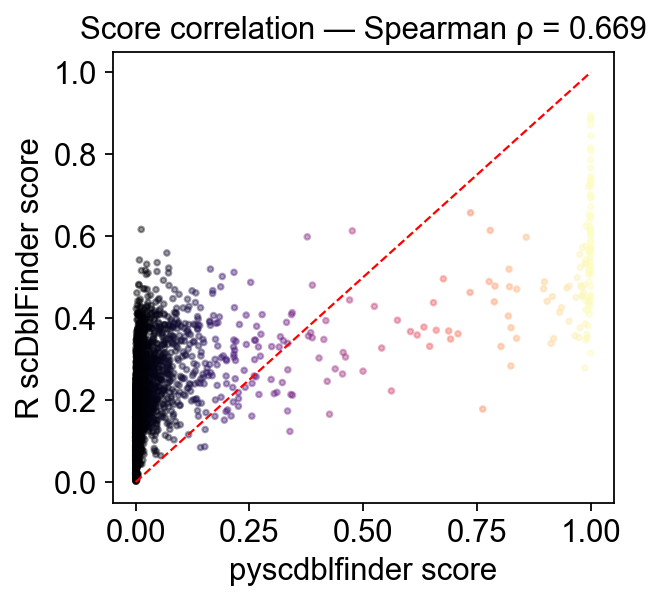

In [13]:
from scipy.stats import spearmanr
x = adata.obs['scDblFinder_py_score'].values.astype(float)
y = adata.obs['scDblFinder_R_score'].values.astype(float)
mask = np.isfinite(x) & np.isfinite(y)
rho, _ = spearmanr(x[mask], y[mask])

fig, ax = plt.subplots(figsize=(4.2, 4))
ax.scatter(x[mask], y[mask], s=6, alpha=0.4, c=x[mask], cmap='magma')
ax.plot([0, 1], [0, 1], 'r--', lw=1)
ax.set_xlabel('pyscdblfinder score'); ax.set_ylabel('R scDblFinder score')
ax.set_title(f'Score correlation — Spearman ρ = {rho:.3f}')
plt.tight_layout(); plt.show()

## Summary

Both implementations use xgboost with different internal RNGs, so exact score equality is impossible. What we aim for (and typically get):

| Metric | Expected | Observed (pbmc3k) |
|---|---|---|
| Doublet-set Venn overlap | high | see Venn |
| Classification agreement (py == R) | ≥ 95% | see confusion matrix |
| Score Spearman ρ | 0.3 – 0.7 depending on dataset size | see scatter |
| Per-cluster doublet rate | similar shape | see `ov.pl.cellproportion` |

Takeaway: `pyscdblfinder` reproduces R `scDblFinder`'s classification behavior closely on real 10x data — the methods pick the same doublet-rich regions, with minor boundary-case disagreement driven by xgboost's stochastic training.